In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import jetset
print(jetset.__version__)

1.4.0rc3


# Model fitting: External Compton with leptonic equilibrium.

## Loading data

In [3]:
from jetset.data_loader import Data,ObsData
from jetset.test_data_helper import  test_SEDs
test_SEDs


['/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/jetset/test_data/SEDs_data/SED_3C345.ecsv',
 '/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/jetset/test_data/SEDs_data/SED_MW_Mrk421_EBL_DEABS.ecsv',
 '/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/jetset/test_data/SEDs_data/SED_MW_Mrk501_EBL_ABS.ecsv',
 '/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/jetset/test_data/SEDs_data/SED_MW_Mrk501_EBL_DEABS.ecsv']

In [4]:
data=Data.from_file(test_SEDs[0])


In [5]:
t=data.table[data.table['dataset']!='-1']

In [6]:
t=t[t['dataset']!='2']

In [7]:
t.write('~/3C454.3.ecsv',overwrite=True)

In [8]:
sed_data=ObsData(data_table=data)

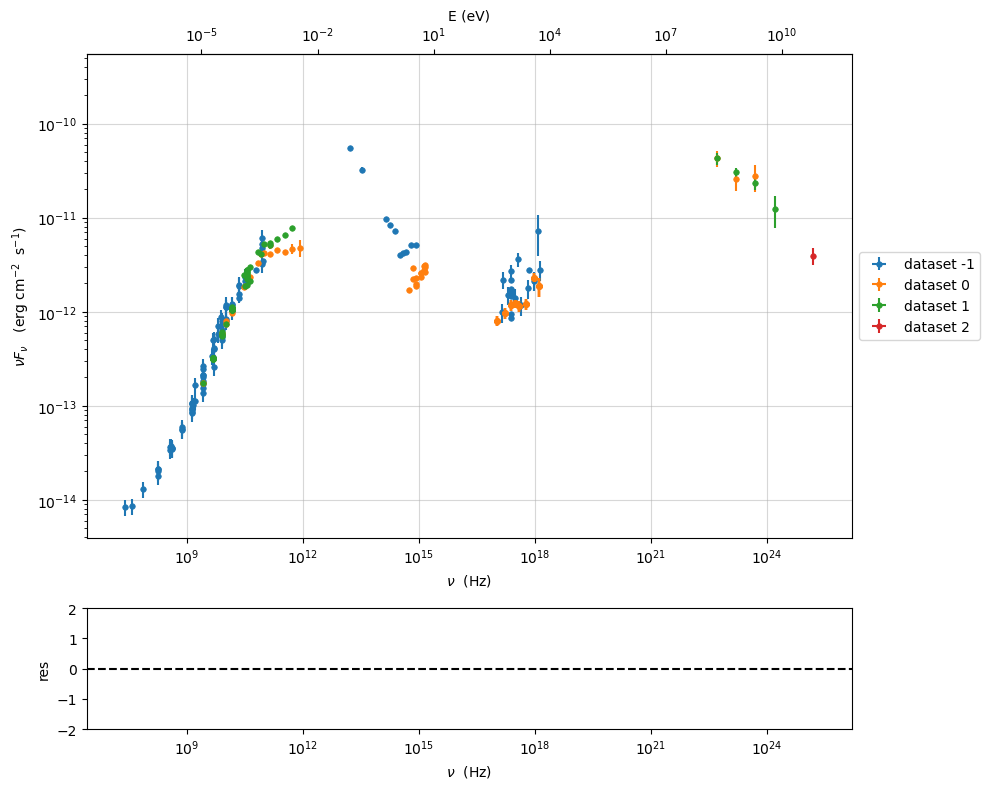

In [9]:
%matplotlib inline
p=sed_data.plot_sed(show_dataset=True)

we filter out the data set `-1` 

current datasets
dataset -1
dataset 0
dataset 1
dataset 2
---> excluding  dataset/s ['-1']
filter -1 192
current datasets
dataset 0
dataset 1
dataset 2
---> data sets left after filtering None
---> data len after filtering=192
---> excluding  dataset/s ['2']
filter 2 191
current datasets
dataset 0
dataset 1
---> data sets left after filtering None
---> data len after filtering=191
current datasets
dataset 0
dataset 1


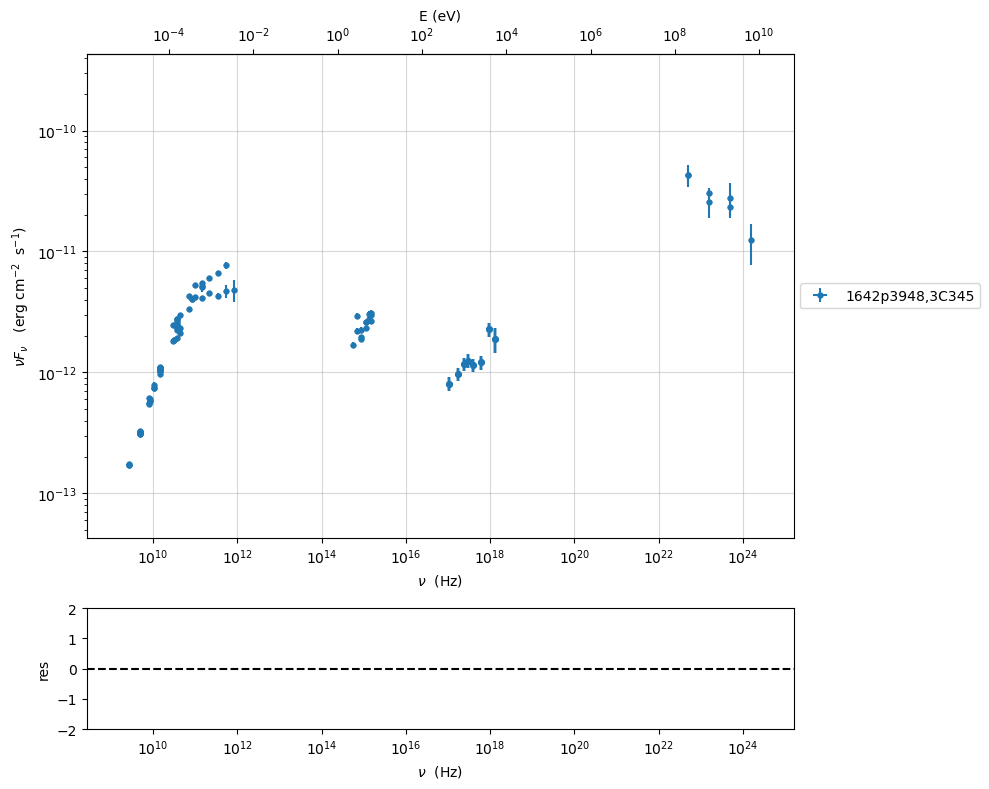

In [10]:
sed_data.show_data_sets()
sed_data.filter_data_set('-1',exclude=True)
sed_data.filter_data_set('2',exclude=True)
sed_data.show_data_sets()
p=sed_data.plot_sed()


In [11]:
sed_data.data.write('~/3C454.3.ecsv',overwrite=True)


***  binning data  ***
---> N bins= 98
---> bin_width= 0.15



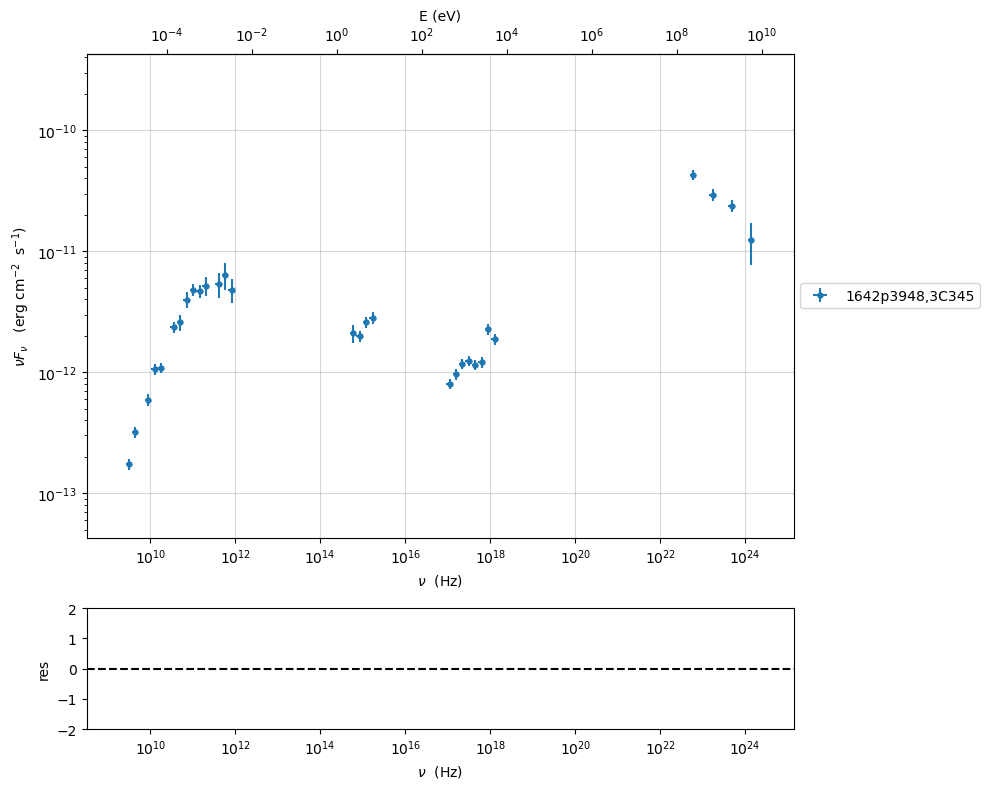

In [12]:
sed_data.group_data(bin_width=.15)
sed_data.add_systematics(0.1,[10.**6,10.**29])
#sed_data.add_systematics(0.05,[10.**19,10.**30])

p=sed_data.plot_sed()

In [13]:
sed_data.save('3C454_data.pkl')

## Phenomenological model constraining


*** evaluating spectral indices for data ***



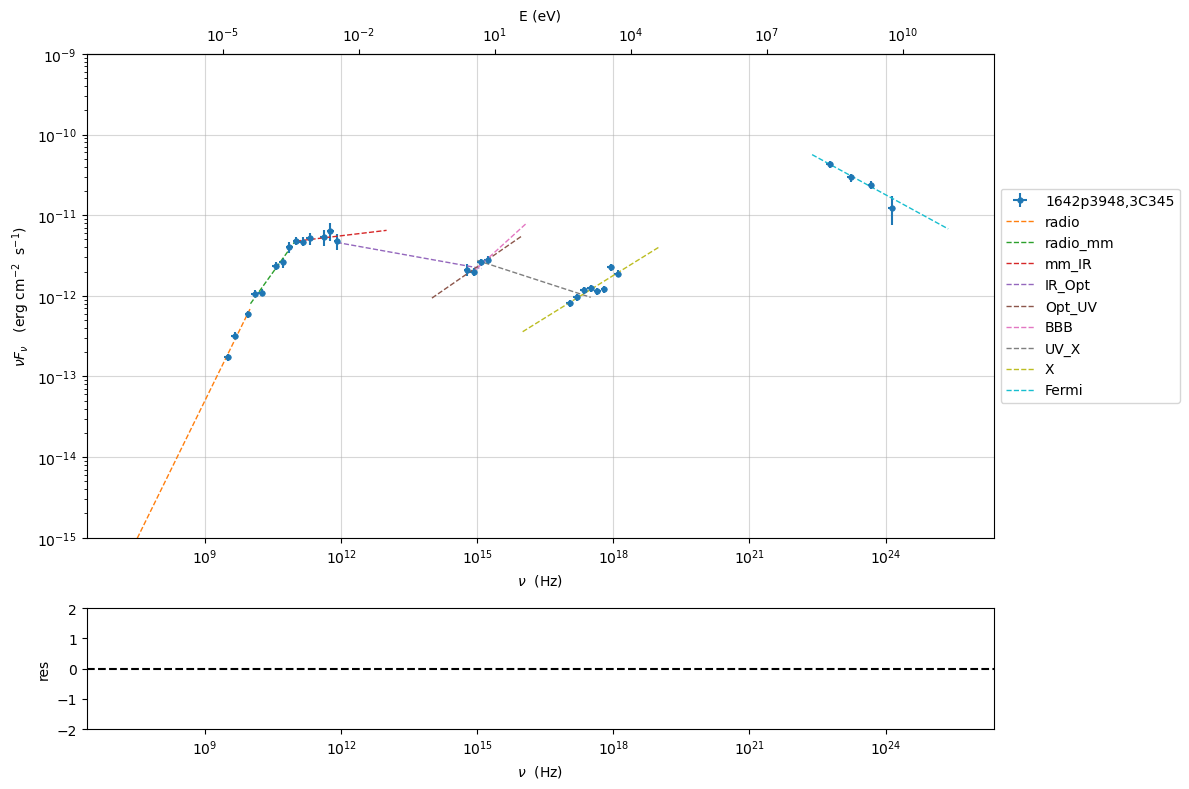

In [14]:
from jetset.sed_shaper import  SEDShape
my_shape=SEDShape(sed_data)
my_shape.eval_indices(silent=True)
p=my_shape.plot_indices()
p.setlim(y_min=1E-15,y_max=1E-9)

for the synchrotron sed_shaping we include the check for Big Blue Bump (BBB) component. Moreover, we force the model to use a pure log-parabolic function and not a log-cubic one in order to get a better estimation of the BBB  component. The fit values of the BBB component will be used in the `ObsConstrain` to guess the accretion disk luminosity and temperature

In [15]:
mm,best_fit=my_shape.sync_fit(check_BBB_template=True,
                              check_host_gal_template=False,
                              use_log_par=True,
                              Ep_start=None,
                              minimizer='lsb',
                              silent=True,
                              fit_range=[9,16])


*** Log-Polynomial fitting of the synchrotron component ***
---> first blind fit run,  fit range: [9, 16]
--> class:  LSP

--> class:  LSP




model name,name,val,bestfit val,err +,err -,start val,fit range min,fit range max,frozen
LogParabolaEp,b,-3.175784e-01,-3.175784e-01,3.360071e-02,--,-1.560612e-01,-1.000000e+01,0.000000e+00,False
LogParabolaEp,Ep,1.167956e+01,1.167956e+01,1.276551e-01,--,1.286767e+01,0.000000e+00,3.000000e+01,False
LogParabolaEp,Sp,-1.123620e+01,-1.123620e+01,4.508175e-02,--,-1.087583e+01,-3.000000e+01,0.000000e+00,False
BBB,nuFnu_p_BBB,-1.156569e+01,-1.156569e+01,2.922622e-02,--,-1.087583e+01,-1.287583e+01,-8.875830e+00,False
BBB,nu_scale,8.865061e-03,8.865061e-03,3.068053e-03,--,0.000000e+00,-5.000000e-01,5.000000e-01,False


---> sync       nu_p=+1.167956e+01 (err=+1.276551e-01)  nuFnu_p=-1.123620e+01 (err=+4.508175e-02) curv.=-3.175784e-01 (err=+3.360071e-02)




*** Log-Polynomial fitting of the IC component ***
---> fit range: [16, 26]
---> LogCubic fit




model name,name,val,bestfit val,err +,err -,start val,fit range min,fit range max,frozen
LogCubic,b,-1.331773e-01,-1.331773e-01,1.456625e-02,--,-1.000000e+00,-1.000000e+01,0.000000e+00,False
LogCubic,c,-1.352785e-02,-1.352785e-02,2.463746e-03,--,-1.000000e+00,-1.000000e+01,1.000000e+01,False
LogCubic,Ep,2.230023e+01,2.230023e+01,1.126805e-01,--,2.228823e+01,0.000000e+00,3.000000e+01,False
LogCubic,Sp,-1.035586e+01,-1.035586e+01,5.102578e-02,--,-1.000000e+01,-3.000000e+01,0.000000e+00,False


---> IC         nu_p=+2.230023e+01 (err=+1.126805e-01)  nuFnu_p=-1.035586e+01 (err=+5.102578e-02) curv.=-1.331773e-01 (err=+1.456625e-02)



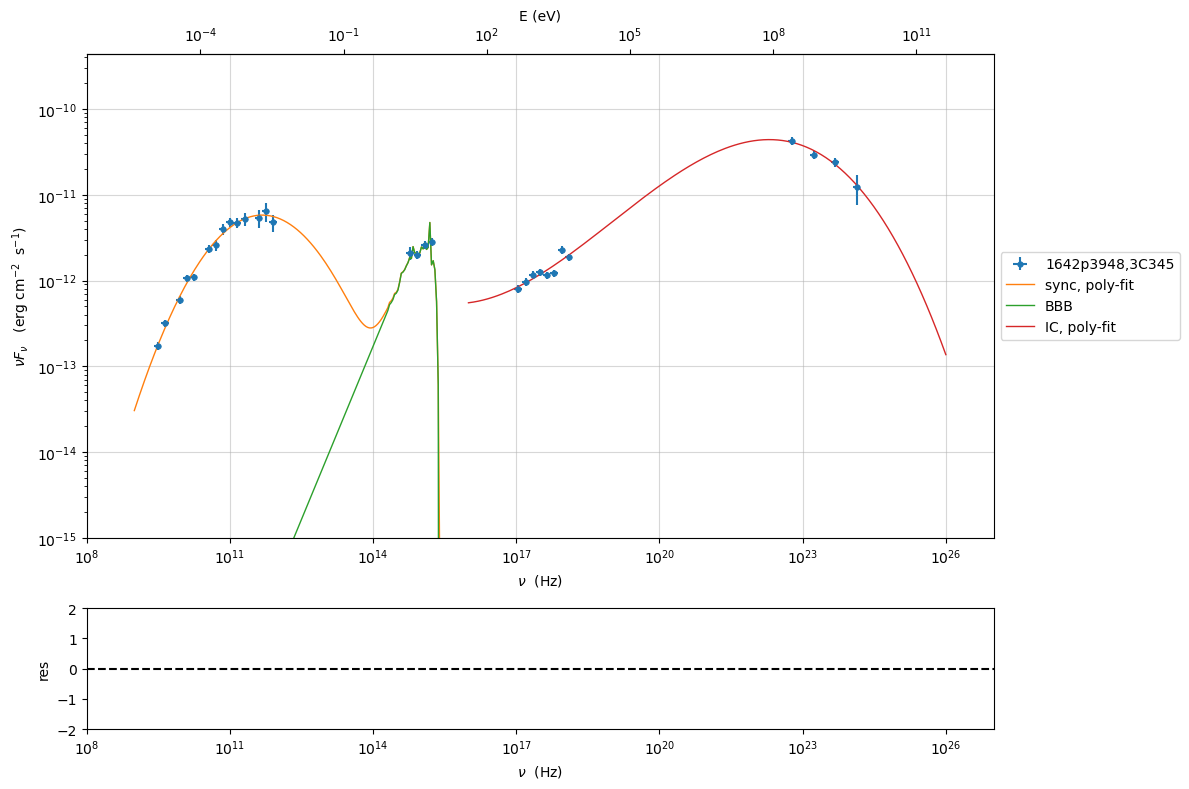

In [16]:
my_shape.IC_fit(fit_range=[16,26],minimizer='minuit', silent=True)
p=my_shape.plot_shape_fit()
p.setlim(y_min=1E-15)

In this case we use the `constrain_SSC_EC_model`, and we ask to use a dusty torus and BLR component external component

In [17]:
from jetset.obs_constrain import ObsConstrain
from jetset.minimizer import fit_SED
sed_obspar=ObsConstrain(B_range=[0.1,0.2],
                        distr_e='bkn',
                        t_var_sec=15*86400,
                        nu_cut_IR=1E9,
                        theta=2,
                        bulk_factor=20,
                        SEDShape=my_shape)


prefit_jet=sed_obspar.constrain_SSC_EC_model(electron_distribution_log_values=False,EC_components_list=['EC_DT','EC_BLR'],R_H=2E18,silent=True,)



***  constrains parameters from observable ***

adding par: L_Disk to  R_BLR_in
==> par R_BLR_in is depending on ['L_Disk'] according to expr:   R_BLR_in =
3E17*(L_Disk/1E46)**0.5
adding par: R_BLR_in to  R_BLR_out
==> par R_BLR_out is depending on ['R_BLR_in'] according to expr:   R_BLR_out =
R_BLR_in*1.1
adding par: L_Disk to  R_DT
==> par R_DT is depending on ['L_Disk'] according to expr:   R_DT =
2E19*(L_Disk/1E46)**0.5


model name,name,par type,units,val,phys. bound. min,phys. bound. max,log,frozen
jet_leptonic,R,region_size,cm,6.764638e+16,1.000000e+03,1.000000e+30,False,False
jet_leptonic,R_H,region_position,cm,2.000000e+18,0.000000e+00,--,False,True
jet_leptonic,B,magnetic_field,gauss,1.500000e-01,0.000000e+00,--,False,False
jet_leptonic,NH_cold_to_rel_e,cold_p_to_rel_e_ratio,,1.000000e+00,0.000000e+00,--,False,True
jet_leptonic,theta,jet-viewing-angle,deg,2.000000e+00,0.000000e+00,9.000000e+01,False,False
jet_leptonic,BulkFactor,jet-bulk-factor,lorentz-factor*,2.000000e+01,1.000000e+00,1.000000e+05,False,False
jet_leptonic,z_cosm,redshift,,5.930000e-01,0.000000e+00,--,False,False
jet_leptonic,gmin,low-energy-cut-off,lorentz-factor*,1.033091e+01,1.000000e+00,1.000000e+09,False,False
jet_leptonic,gmax,high-energy-cut-off,lorentz-factor*,1.351959e+04,1.000000e+00,1.000000e+15,False,False
jet_leptonic,N,emitters_density,1 / cm3,1.145713e+03,0.000000e+00,--,False,False


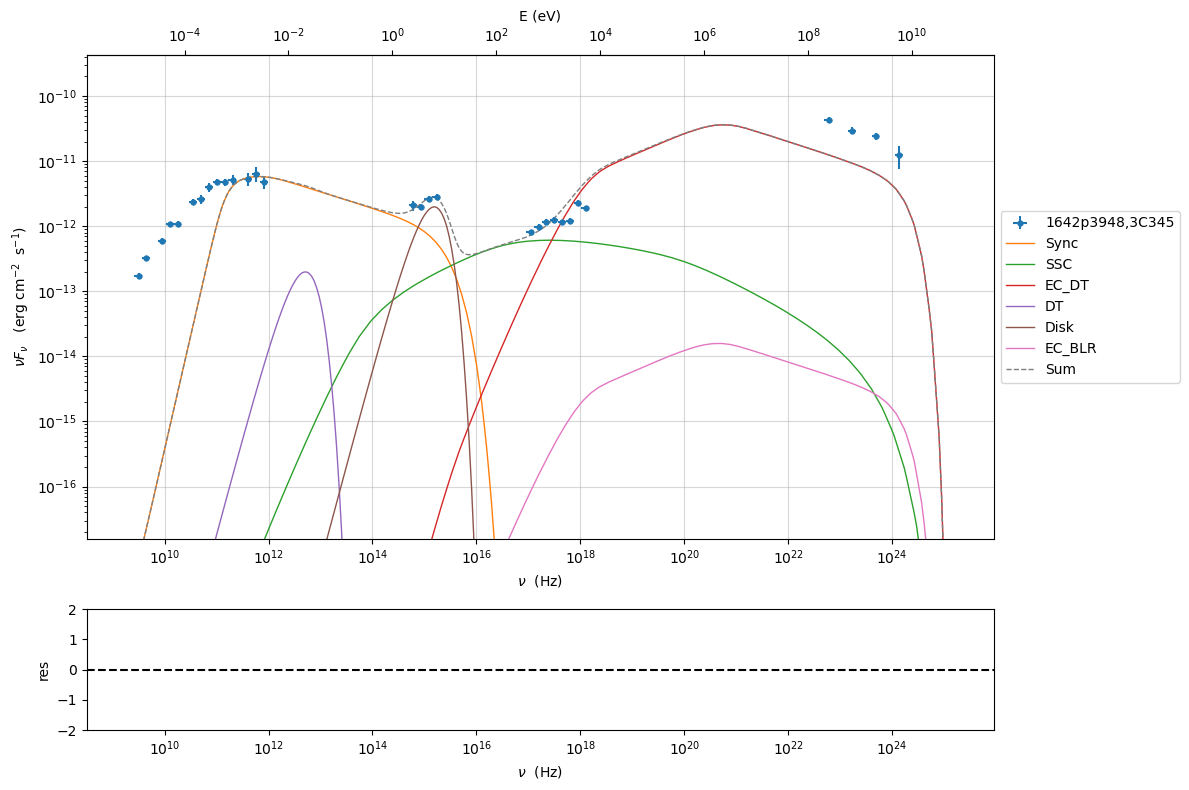

In [18]:
prefit_jet.eval()
p=prefit_jet.plot_model(sed_data=sed_data)

In [19]:
prefit_jet.make_conical_jet(theta_open=5)

adding par: R_H to  R
adding par: theta_open to  R
==> par R is depending on ['R_H', 'theta_open'] according to expr:   R =
np.tan(np.radians(theta_open))*R_H
setting R_H to 7.732016219800707e+17


In [20]:
prefit_jet.set_EC_dependencies()

==> par R_BLR_in is depending on ['L_Disk'] according to expr:   R_BLR_in =
3E17*(L_Disk/1E46)**0.5
==> par R_BLR_out is depending on ['R_BLR_in'] according to expr:   R_BLR_out =
R_BLR_in*1.1
==> par R_DT is depending on ['L_Disk'] according to expr:   R_DT =
2E19*(L_Disk/1E46)**0.5


In [21]:
prefit_jet.set_external_field_transf('disk')

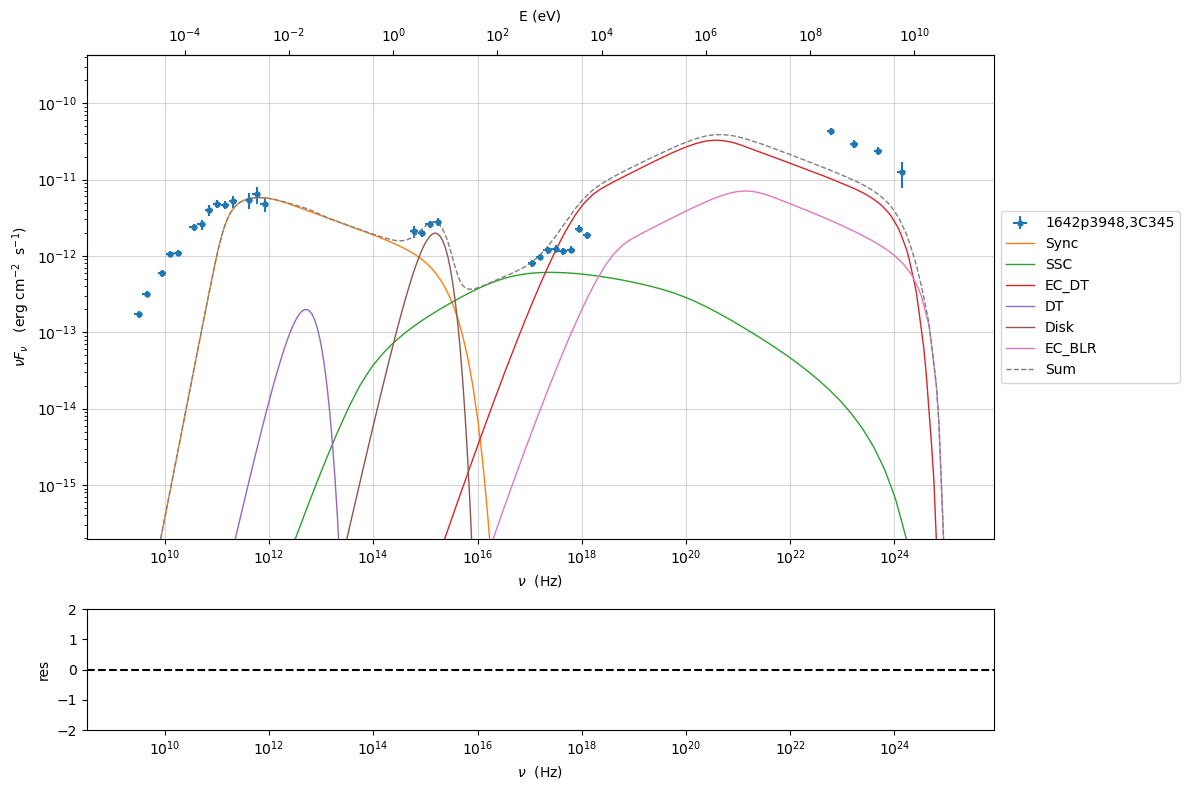

In [22]:
prefit_jet.eval()
p=prefit_jet.plot_model(sed_data=sed_data)


## Enabling the leptonic equilibrium

We change the emitters distribution for the `prefit_jet` model. We just preserve the original values of `gmin` and `gmax`


In [23]:
from jetset.jet_emitters_factory import InjEmittersFactory
gmin=prefit_jet.parameters.gmin.val
gmax=prefit_jet.parameters.gmax.val
p=prefit_jet.parameters.p.val
q_inj = InjEmittersFactory().create_inj_emitters('pl')
prefit_jet.set_emitters_distribution(q_inj)
prefit_jet.parameters.gmin.val=gmin
prefit_jet.parameters.gmax.val=gmax
prefit_jet.parameters.p.val=p



We change the name of the jet model (this is not necessary)


In [24]:
prefit_jet.name='leptonic_eq'

We renormalize the injected Luminosity in order to get a flux level consistent with the date, we can use the usual method `set_N_from_nuFnu`, it will work.

In [25]:
prefit_jet.set_N_from_nuFnu(nu_obs=1E12,nuFnu_obs=8E-12)

In [26]:
prefit_jet.parameters

model name,name,par type,units,val,phys. bound. min,phys. bound. max,log,frozen
leptonic_eq,"*R(D,theta_open)",region_size,cm,6.764638e+16,1.000000e+03,1.000000e+30,False,True
leptonic_eq,R_H(M),region_position,cm,7.732016e+17,0.000000e+00,--,False,False
leptonic_eq,B,magnetic_field,gauss,1.500000e-01,0.000000e+00,--,False,False
leptonic_eq,NH_cold_to_rel_e,cold_p_to_rel_e_ratio,,1.000000e+00,0.000000e+00,--,False,True
leptonic_eq,theta,jet-viewing-angle,deg,2.000000e+00,0.000000e+00,9.000000e+01,False,False
leptonic_eq,BulkFactor,jet-bulk-factor,lorentz-factor*,2.000000e+01,1.000000e+00,1.000000e+05,False,False
leptonic_eq,z_cosm,redshift,,5.930000e-01,0.000000e+00,--,False,False
leptonic_eq,T_DT,DT,K,1.000000e+02,0.000000e+00,--,False,False
leptonic_eq,"*R_DT(D,L_Disk)",DT,cm,1.292162e+19,0.000000e+00,--,False,True
leptonic_eq,tau_DT,DT,,1.000000e-01,0.000000e+00,1.000000e+00,False,False


None

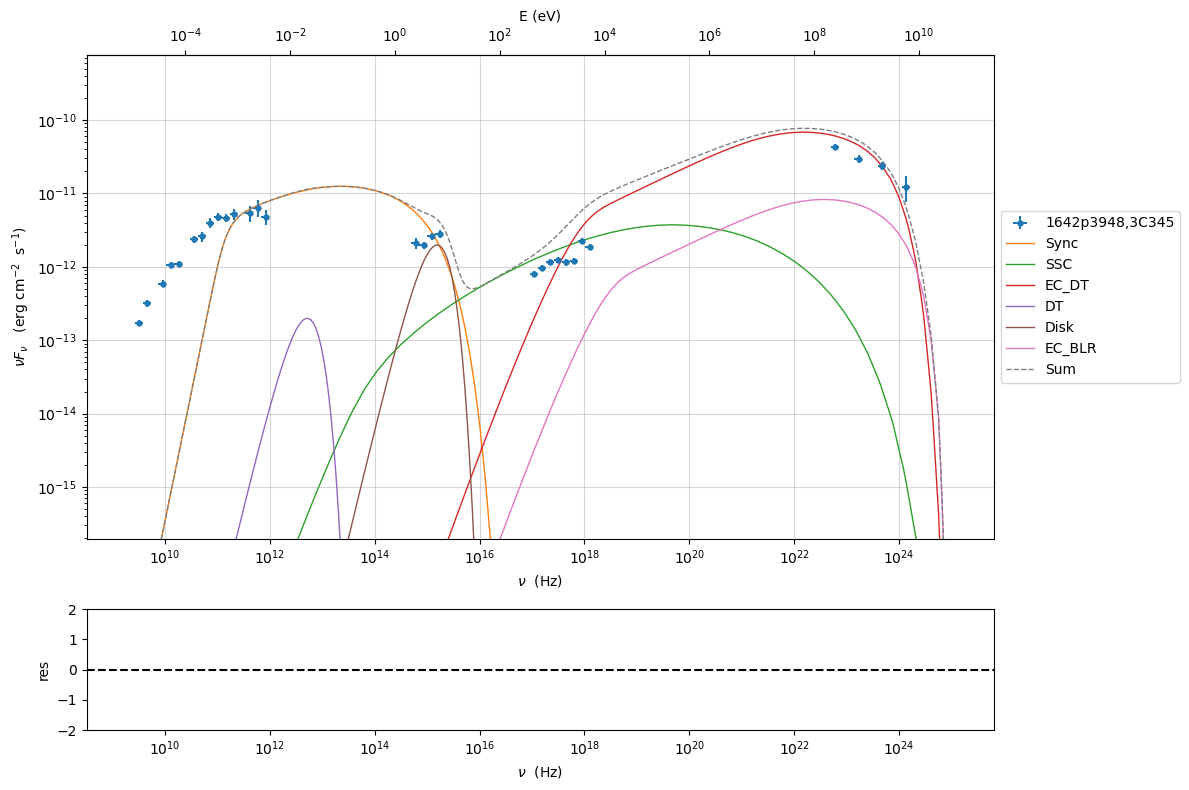

In [27]:
prefit_jet.eval()
p=prefit_jet.plot_model(sed_data=sed_data)
prefit_jet.save_model('prefit_jet_EC.pkl')


The prefit model should works well for the synchrotron component, but the EC one is a bit problematic. We can set as starting values  a slightly harder value of `p`, and a larger value of `gamma_break` and `gmax`. We freeze some parameters, and we also set some `fit_range` values. Setting fit_range can speed-up the fit convergence but should be judged by the user each time according to the physics of the particular source

## EC model fit

In [28]:
from jetset.data_loader import ObsData
sed_data=ObsData.load('3C454_data.pkl')
from jetset.jet_model import Jet

In [29]:
from jetset.model_manager import  FitModel
jet=Jet.load_model('prefit_jet_EC.pkl')
jet.set_gamma_grid_size(100)
fit_model=FitModel( jet=jet, name='EC-best-fit-lsb')
fit_model.show_model_components()


--------------------------------------------------------------------------------
Composite model description
--------------------------------------------------------------------------------
name: EC-best-fit-lsb  
type: composite_model  
components models:
 -model name: leptonic_eq model type: jet

--------------------------------------------------------------------------------


### Setting the fit range for the model parameters

In [30]:

fit_model.freeze('leptonic_eq','z_cosm')
fit_model.freeze('leptonic_eq','theta')

fit_model.free('leptonic_eq','R_H')
fit_model.freeze('leptonic_eq','L_Disk')
fit_model.freeze('leptonic_eq','tau_DT')
fit_model.freeze('leptonic_eq','tau_BLR')

fit_model.leptonic_eq.parameters.R_H.fit_range=[5E17,5E19]
fit_model.leptonic_eq.parameters.T_Disk.fit_range=[1E4,1E5]
fit_model.leptonic_eq.parameters.T_DT.fit_range=[100,1000]
fit_model.leptonic_eq.parameters.gmax.fit_range=[1E4,1E5]
fit_model.leptonic_eq.parameters.gmin.fit_range=[1,1000]

fit_model.leptonic_eq.parameters.B.fit_range=[1E-2,2]
fit_model.leptonic_eq.parameters.p.fit_range=[2.0,3.5]
fit_model.leptonic_eq.parameters.theta_open.fit_range=[4,6]
fit_model.leptonic_eq.parameters.BulkFactor.fit_range=[10,30]
fit_model.leptonic_eq.parameters.L_inj.fit_range=[1E41,1E44]
fit_model.leptonic_eq.parameters.T_esc_e_primaries.fit_range=[1,2]

### How to enable Internal absorption 

If you want to enable the `DT` absorption, you can use this instruction

```python
fit_model.jet_leptonic.enable_internal_absorption('DT')
```


In [31]:
fit_model.leptonic_eq.enable_internal_absorption('DT',use_R_H_profile_extrapolation=True)


### Run the fit 

In [32]:
from jetset.minimizer import ModelMinimizer
model_minimizer=ModelMinimizer('minuit')
best_fit=model_minimizer.fit(fit_model,sed_data,3E10,1E29,fitname='EC-best-fit-lsb',repeat=2)

filtering data in fit range = [3.000000e+10,1.000000e+29]
data length 25

*** start fit process ***
----- 
fit run: 0


0it [00:00, ?it/s]

- best chisq=2.10929e+02

fit run: 1
- old chisq=2.10929e+02


0it [00:00, ?it/s]

- best chisq=1.01287e+02

-------------------------------------------------------------------------
Fit report

Model: EC-best-fit-lsb


...


converged=True
calls=4600
mesg=


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 101.3                      │             Nfcn = 4600              │
│ EDM = 581 (Goal: 0.0002)         │           time = 68.1 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│         INVALID Minimum          │   ABOVE EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │     Covariance FORCED pos. def.      │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name   │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ par_0  │  16.935   │   0.007   │            │            │    1    │  1000   │       │
│ 1 │ par_1  │ 10.203e3  │  0.010e3  │            │            │  10000  │ 100000  │       │
│ 2 │ par_2  │  2.39712  │  0.00014  │            │            │    2    │   3.5   │       │
│ 3 │ par_3  │  1.75232  │  0.00006  │            │            │    1    │    2    │       │
│ 4 │ par_4  │  36.3e42  │  0.8e42   │            │            │  1e+41  │  1e+44  │       │
│ 5 │ par_5  │    642    │     9     │            │            │   100   │  1000   │       │
│ 6 │ par_6  │  25.1e3   │   1.7e3   │            │            │  10000  │ 100000  │       │
│ 7 │ par_7  │  3.27e18  │  0.12e18  │            │            │  5e+17  │  5e+19  │       │
│ 8 │ par_8  │  0.0802   │  0.0027   │            │            │  0.01   │    2    │       │
│ 9 │ par_9  │  10.1319  │  0.0008   │            │            │   10    │   30    │       │
│ 10│ par_10 │ 5.637513  │ 0.000035  │            │            │    4    │    6    │       │
└───┴────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘

dof=14
chisq=101.286666, chisq/red=7.234762 null hypothesis sig=0.000000

best fit pars


model name,name,val,bestfit val,err +,err -,start val,fit range min,fit range max,frozen
leptonic_eq,gmin,1.693490e+01,1.693490e+01,6.720767e-03,--,1.033091e+01,1.000000e+00,1.000000e+03,False
leptonic_eq,gmax,1.020300e+04,1.020300e+04,9.967803e+00,--,1.351959e+04,1.000000e+04,1.000000e+05,False
leptonic_eq,p,2.397116e+00,2.397116e+00,1.361033e-04,--,2.301767e+00,2.000000e+00,3.500000e+00,False
leptonic_eq,T_esc_e_primaries,1.752319e+00,1.752319e+00,5.736321e-05,--,1.000000e+00,1.000000e+00,2.000000e+00,False
leptonic_eq,L_inj,3.633196e+43,3.633196e+43,7.913417e+41,--,1.881392e+43,1.000000e+41,1.000000e+44,False
leptonic_eq,T_DT,6.418251e+02,6.418251e+02,9.272468e+00,--,1.000000e+02,1.000000e+02,1.000000e+03,False
leptonic_eq,"*R_DT(D,L_Disk)",1.292162e+19,--,--,--,1.292162e+19,0.000000e+00,--,True
leptonic_eq,tau_DT,1.000000e-01,--,--,--,1.000000e-01,0.000000e+00,1.000000e+00,True
leptonic_eq,tau_BLR,1.000000e-01,--,--,--,1.000000e-01,0.000000e+00,1.000000e+00,True
leptonic_eq,"*R_BLR_in(D,L_Disk)",1.938243e+17,--,--,--,1.938243e+17,0.000000e+00,--,True


-------------------------------------------------------------------------




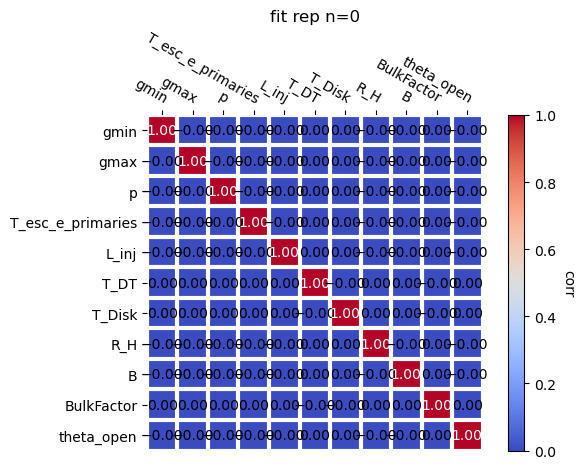

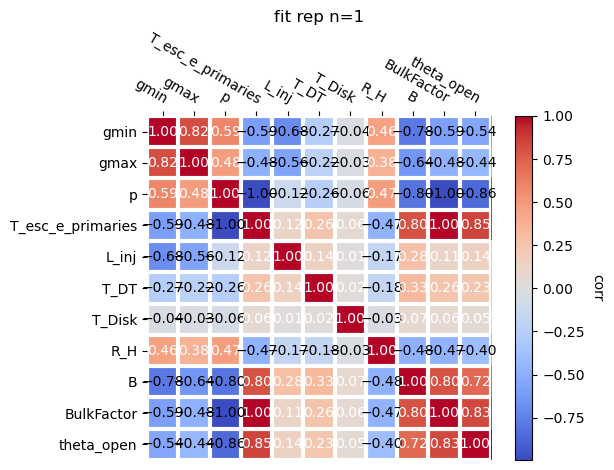

In [33]:
p=model_minimizer.plot_corr_matrix()

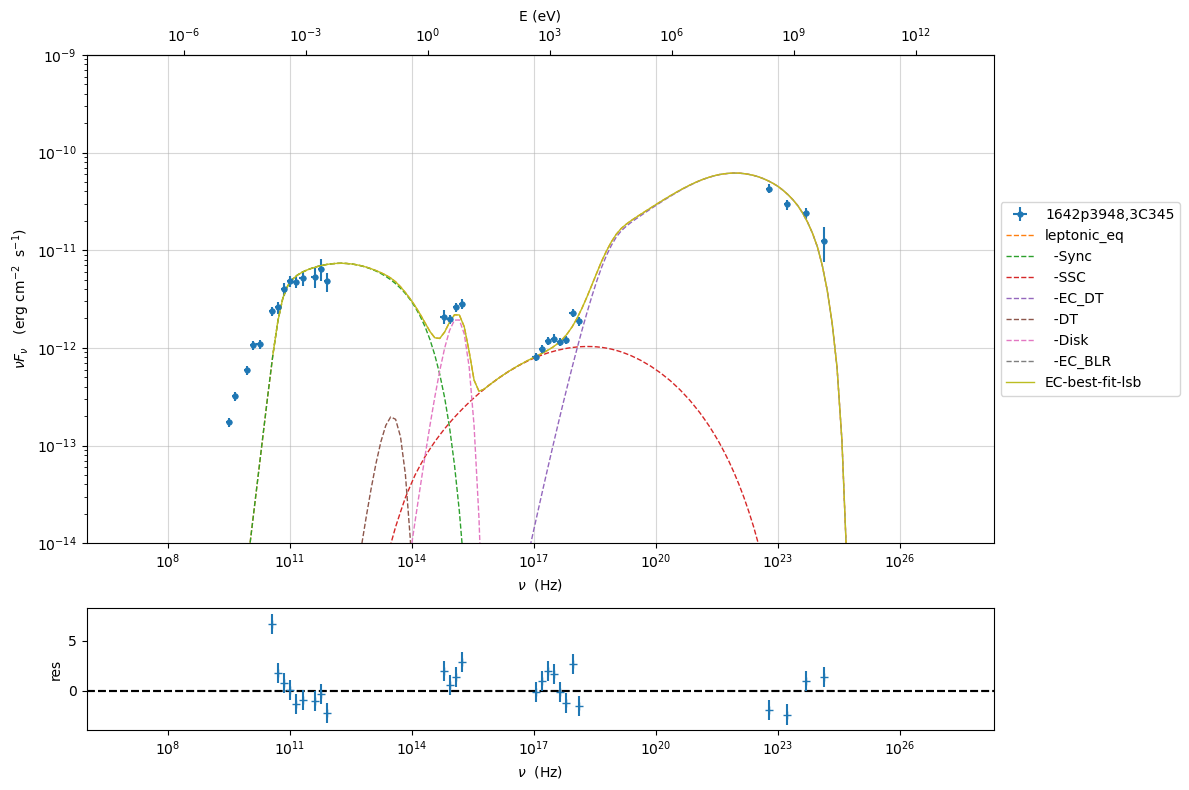

In [34]:
%matplotlib inline
fit_model.set_nu_grid(1E6,1E30,200)
fit_model.eval()
p2=fit_model.plot_model(sed_data=sed_data)
p2.setlim(y_min=1E-14,y_max=1E-9,x_min=1E6,x_max=2E28)

In [35]:
jet.energetic_report()

name,type,units,val
BulkLorentzFactor,jet-bulk-factor,,1.013187e+01
U_e,Energy dens. blob rest. frame,erg / cm3,3.923847e-03
U_p_cold,Energy dens. blob rest. frame,erg / cm3,1.503276e-01
U_B,Energy dens. blob rest. frame,erg / cm3,2.560946e-04
U_Synch,Energy dens. blob rest. frame,erg / cm3,1.797771e-05
U_Synch_DRF,Energy dens. disk rest. frame,erg / cm3,1.879590e+00
U_Disk,Energy dens. blob rest. frame,erg / cm3,3.204691e-06
U_BLR,Energy dens. blob rest. frame,erg / cm3,2.655555e-07
U_DT,Energy dens. blob rest. frame,erg / cm3,1.367122e-03
U_Corona,Energy dens. blob rest. frame,erg / cm3,0.000000e+00


In [36]:
best_fit.save_report('EC-best-fit-minuit.pkl')
model_minimizer.save_model('EC_model_minimizer_minuit.pkl')
fit_model.save_model('EC_fit_model_minuit.pkl')

## MCMC sampling


In [37]:
from jetset.mcmc import McmcSampler
from jetset.minimizer import ModelMinimizer
model_minimizer_minuit = ModelMinimizer.load_model('EC_model_minimizer_minuit.pkl')


In [38]:
mcmc=McmcSampler(model_minimizer_minuit)


You can inspect the mcmc parameters using:


In [39]:
mcmc.sampler_parameters

model name,name,val,log,bestfit mcmc,q16,q50,q84,mcmc bound min,mcmc bound max,frozen
str11,str22,float64,bool,float64,float64,float64,float64,float64,float64,bool
leptonic_eq,gmin,1.693490e+01,False,1.693490e+01,--,--,--,1.000000e+00,1.000000e+03,False
leptonic_eq,gmax,1.020300e+04,False,1.020300e+04,--,--,--,1.000000e+04,1.000000e+05,False
leptonic_eq,p,2.397116e+00,False,2.397116e+00,--,--,--,2.000000e+00,3.500000e+00,False
leptonic_eq,T_esc_e_primaries,1.752319e+00,False,1.752319e+00,--,--,--,1.000000e+00,2.000000e+00,False
leptonic_eq,L_inj,3.633196e+43,False,3.633196e+43,--,--,--,1.000000e+41,1.000000e+44,False
leptonic_eq,T_DT,6.418251e+02,False,6.418251e+02,--,--,--,1.000000e+02,1.000000e+03,False
leptonic_eq,T_Disk,2.508528e+04,False,2.508528e+04,--,--,--,1.000000e+04,1.000000e+05,False
leptonic_eq,R_H(M),3.274550e+18,False,3.274550e+18,--,--,--,5.000000e+17,5.000000e+19,False
leptonic_eq,B,8.022693e-02,False,8.022693e-02,--,--,--,1.000000e-02,2.000000e+00,False



If you want to exclude or include parameters from the samplers just freeze/free them.


In [41]:
mcmc.model.leptonic_eq.parameters.freeze_all()
mcmc.model.leptonic_eq.parameters.L_inj.free()
mcmc.model.leptonic_eq.parameters.B.free()
mcmc.model.leptonic_eq.parameters.BulkFactor.free()
mcmc.model.leptonic_eq.parameters.p.free()

In [42]:
mcmc.set_bounds(bound=5.0,bound_rel=True)

par: p  ref value:  2.397116000722639  mcmc bounds: [2.0, 3.5]
par: L_inj  ref value:  3.633196290126969e+43  mcmc bounds: [1e+41, 1e+44]
par: B  ref value:  0.08022692844155532  mcmc bounds: [0.01, np.float64(0.48136157064933194)]
par: BulkFactor  ref value:  10.131873517869163  mcmc bounds: [10, 30]



Or, you can set per-parameter bounds as follows, passing the actual bound for each parameter.


You can set different bounds for all the free parameters with the instruction below. In case you want to preserve the `fit_range` defined in the frequentist minimizer you can pass `preserve_fit_range=True`


In [43]:
mcmc.set_bounds(bound=5.0,bound_rel=True)

par: p  ref value:  2.397116000722639  mcmc bounds: [2.0, 3.5]
par: L_inj  ref value:  3.633196290126969e+43  mcmc bounds: [1e+41, 1e+44]
par: B  ref value:  0.08022692844155532  mcmc bounds: [0.01, np.float64(0.48136157064933194)]
par: BulkFactor  ref value:  10.131873517869163  mcmc bounds: [10, 30]


Or, you can set per-parameter bounds as follows, passing the actual bound for each parameter.

In [46]:
mcmc.set_bounds(comp_name='leptonic_eq',par_name='L_inj',par_bounds=[1E42,1E44])


par: L_inj  ref value:  3.633196290126969e+43  mcmc bounds: [1e+42, 1e+44]


In [47]:
mcmc.sampler_parameters

model name,name,val,log,bestfit mcmc,q16,q50,q84,mcmc bound min,mcmc bound max,frozen
str11,str22,float64,bool,float64,float64,float64,float64,float64,float64,bool
leptonic_eq,p,2.397116e+00,False,2.397116e+00,--,--,--,2.000000e+00,3.500000e+00,False
leptonic_eq,L_inj,3.633196e+43,False,3.633196e+43,--,--,--,1.000000e+42,1.000000e+44,False
leptonic_eq,B,8.022693e-02,False,8.022693e-02,--,--,--,1.000000e-02,4.813616e-01,False
leptonic_eq,BulkFactor,1.013187e+01,False,1.013187e+01,--,--,--,1.000000e+01,3.000000e+01,False
leptonic_eq,gmin,1.693490e+01,False,--,--,--,--,1.000000e+00,1.000000e+03,True
leptonic_eq,gmax,1.020300e+04,False,--,--,--,--,1.000000e+04,1.000000e+05,True
leptonic_eq,T_esc_e_primaries,1.752319e+00,False,--,--,--,--,1.000000e+00,2.000000e+00,True
leptonic_eq,T_DT,6.418251e+02,False,--,--,--,--,1.000000e+02,1.000000e+03,True
leptonic_eq,"*R_DT(D,L_Disk)",1.292162e+19,False,--,--,--,--,0.000000e+00,--,True


In [48]:
mcmc.run_sampler(nwalkers=20, burnin=50,steps=500,progress='notebook')

mcmc run starting



  0%|          | 0/500 [00:00<?, ?it/s]

mcmc run done, with 1 threads took 151.85 seconds
----------------------------
MCMC best fit solution
comp: leptonic_eq par: p  mcmc best fit val: 2.4322576051068086 quantiles(0.16,0.5,0.84): [2.39352515 2.42821897 2.46045085] 
comp: leptonic_eq par: L_inj  mcmc best fit val: 4.0068970932930744e+43 quantiles(0.16,0.5,0.84): [3.56343438e+43 3.85862047e+43 4.21490743e+43] 
comp: leptonic_eq par: B  mcmc best fit val: 0.07786055463241438 quantiles(0.16,0.5,0.84): [0.07543874 0.07924354 0.0827114 ] 
comp: leptonic_eq par: BulkFactor  mcmc best fit val: 10.00412956846212 quantiles(0.16,0.5,0.84): [10.017384   10.06766745 10.17279078] 
----------------------------


Showing the MCMC parameters. Now MCMC bestfit values are updated to the best-fit MCMC solution


In [49]:
mcmc.sampler_parameters

model name,name,val,log,bestfit mcmc,q16,q50,q84,mcmc bound min,mcmc bound max,frozen
str11,str22,float64,bool,float64,float64,float64,float64,float64,float64,bool
leptonic_eq,p,2.432258e+00,False,2.432258e+00,2.393525e+00,2.428219e+00,2.460451e+00,2.000000e+00,3.500000e+00,False
leptonic_eq,L_inj,4.006897e+43,False,4.006897e+43,3.563434e+43,3.858620e+43,4.214907e+43,1.000000e+42,1.000000e+44,False
leptonic_eq,B,7.786055e-02,False,7.786055e-02,7.543874e-02,7.924354e-02,8.271140e-02,1.000000e-02,4.813616e-01,False
leptonic_eq,BulkFactor,1.000413e+01,False,1.000413e+01,1.001738e+01,1.006767e+01,1.017279e+01,1.000000e+01,3.000000e+01,False
leptonic_eq,gmin,1.693490e+01,False,--,--,--,--,1.000000e+00,1.000000e+03,True
leptonic_eq,gmax,1.020300e+04,False,--,--,--,--,1.000000e+04,1.000000e+05,True
leptonic_eq,T_esc_e_primaries,1.752319e+00,False,--,--,--,--,1.000000e+00,2.000000e+00,True
leptonic_eq,T_DT,6.418251e+02,False,--,--,--,--,1.000000e+02,1.000000e+03,True
leptonic_eq,"*R_DT(D,L_Disk)",1.292162e+19,False,--,--,--,--,0.000000e+00,--,True



### post-run tuning of the burnin
We plot the chains, before and after, tuning the burnin (using autocorrelation time of emcee).


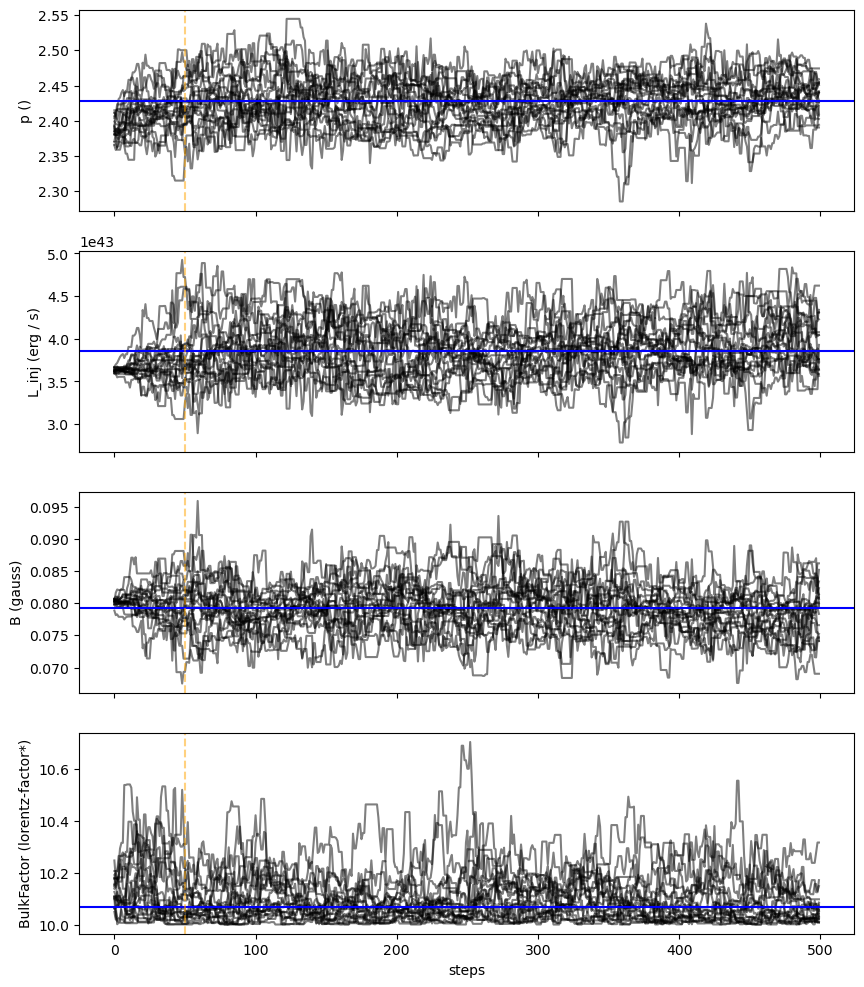

In [50]:
p=mcmc.plot_chain()



In [51]:
mcmc.tune_burnin(tau_coeff=2)


----------------------------
MCMC best fit solution
comp: leptonic_eq par: p  mcmc best fit val: 2.4322576051068086 quantiles(0.16,0.5,0.84): [2.3936214  2.42858165 2.46027333] 
comp: leptonic_eq par: L_inj  mcmc best fit val: 4.0068970932930744e+43 quantiles(0.16,0.5,0.84): [3.56578027e+43 3.86106661e+43 4.21222227e+43] 
comp: leptonic_eq par: B  mcmc best fit val: 0.07786055463241438 quantiles(0.16,0.5,0.84): [0.07546799 0.07920784 0.08265862] 
comp: leptonic_eq par: BulkFactor  mcmc best fit val: 10.00412956846212 quantiles(0.16,0.5,0.84): [10.01720334 10.06807879 10.17349471] 
----------------------------


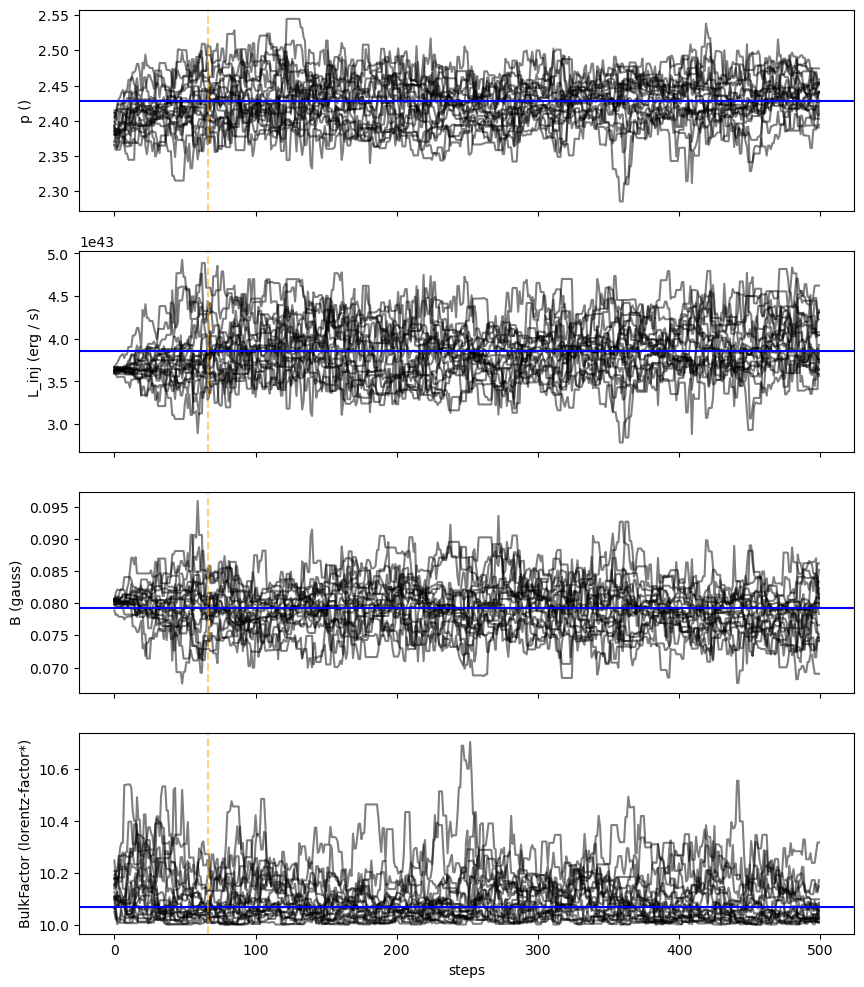

In [52]:
p=mcmc.plot_chain()

The updated burnin value has increased compared to the initial one, now the chain samples a parameter space closer to the convergence.

### plotting the posterior corner plot

To have a better rendering on the scatter plot, we redefine the plot labels


In [58]:
mcmc.set_plot_label('L_inj',r'$L_{\rm inj}$',comp_name='leptonic_eq')
mcmc.set_plot_label('B',r'$B$',comp_name='leptonic_eq')
mcmc.set_plot_label('p',r'$p$',comp_name='leptonic_eq')
mcmc.set_plot_label('BulkFactor',r'$\Gamma$',comp_name='leptonic_eq')



The code below lets you tune the output.

1. ``mpl.rcParams['figure.dpi']``: increase it to get better definition.
2. ``title_fmt='.2E'``: Python format with 2 significant digits in scientific notation.
3. ``title_kwargs=dict(fontsize=12)``: change the title font size.


Per-component corner plot

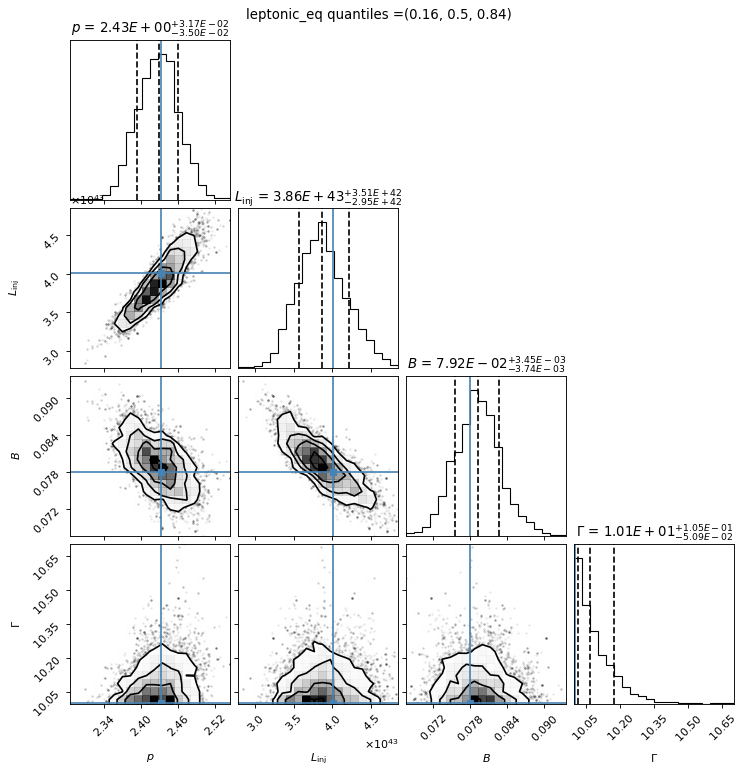

In [59]:
import matplotlib as mpl

mpl.rcParams['figure.dpi'] = 80
f=mcmc.corner_plot(quantiles=(0.16, 0.5, 0.84),title_kwargs=dict(fontsize=12),title_fmt=".2E",use_math_text=True)

### plotting the model

To plot the sampled model range against the input mcmc best-fit model


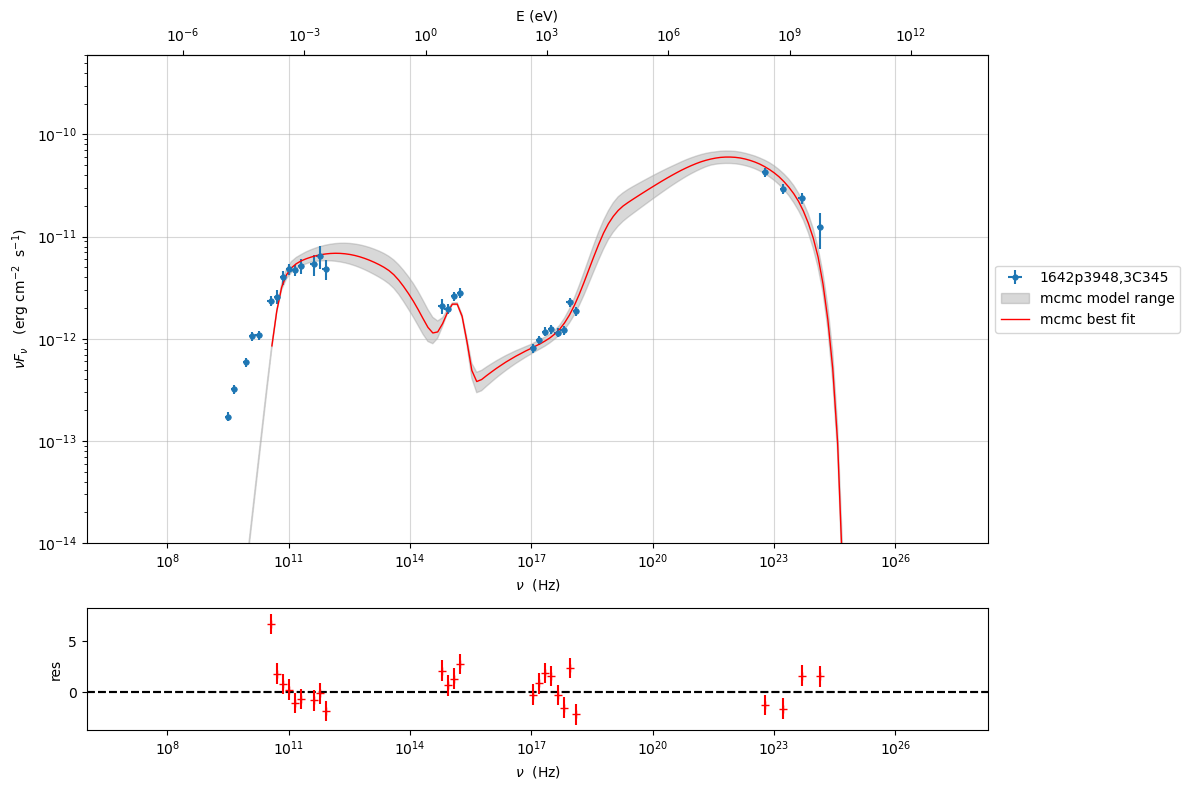

In [60]:
mpl.rcParams['figure.dpi'] = 80
p=mcmc.plot_model(sed_data=sed_data,size=500)
p.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

To plot the mcmc best-fit model providing quantiles. The size parameter defines the number of samples to use to extract the quantiles. I am using a size equal to the number of steps


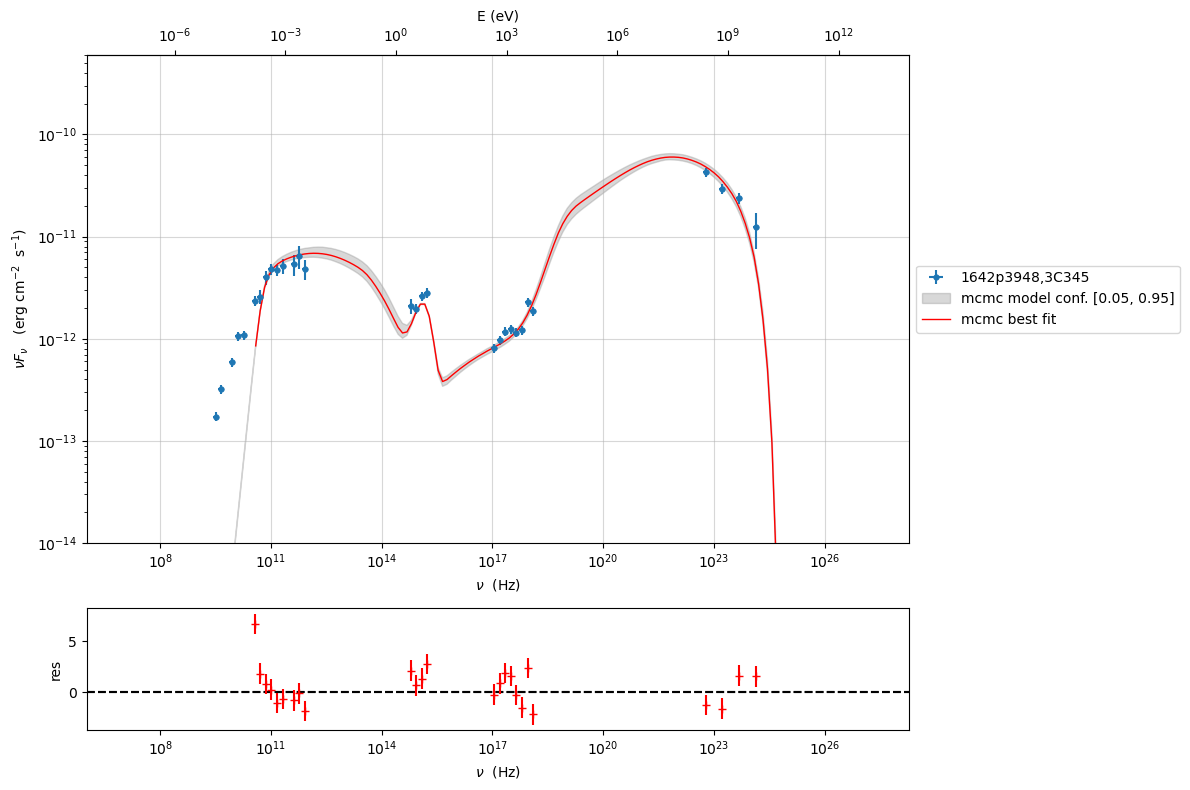

In [61]:
mpl.rcParams['figure.dpi'] = 80
p=mcmc.plot_model(sed_data=sed_data,size=500,quantiles=[0.05,0.95])
p.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

If you want to plot also the model components, pass the argument `plot_components=True`

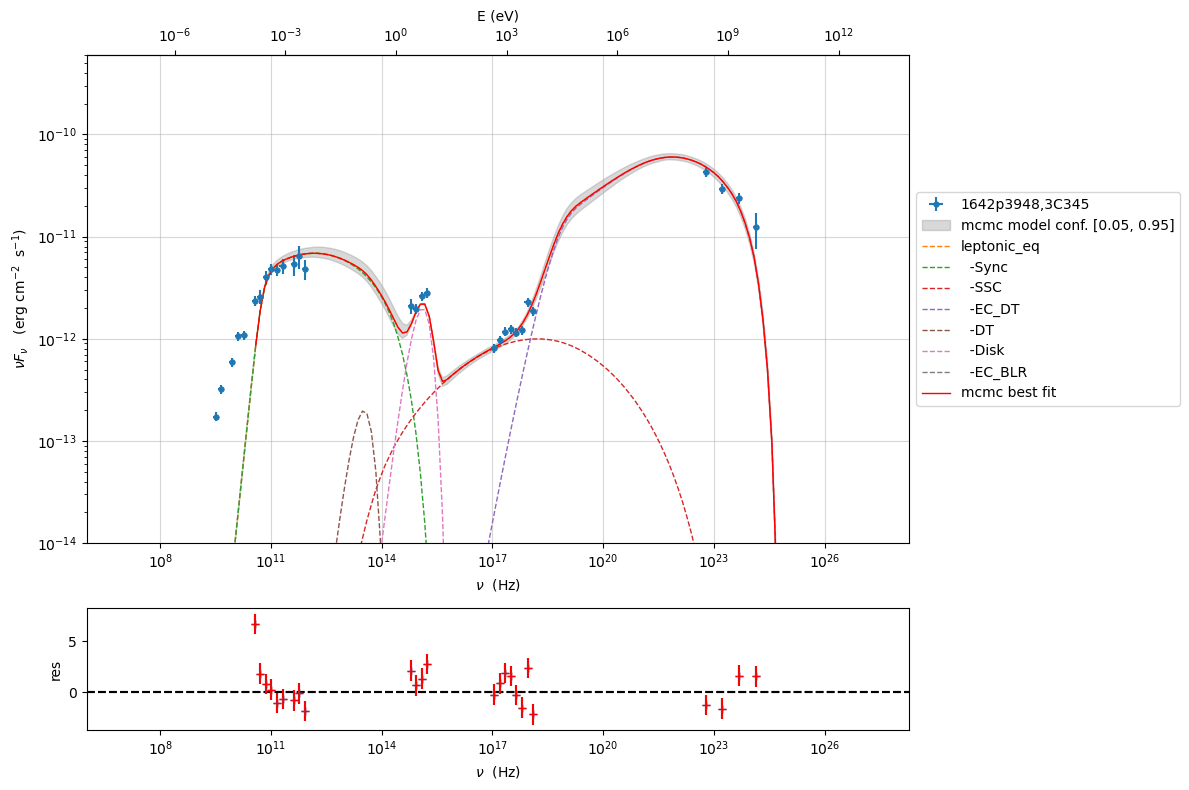

In [62]:
mpl.rcParams['figure.dpi'] = 80
p=mcmc.plot_model(sed_data=sed_data,size=500,quantiles=[0.05,0.95],plot_components=True)
p.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

To plot the frequentist  best-fit  model range, providing quantiles, provide (``plot_mcmc_best_fit_model=False``)

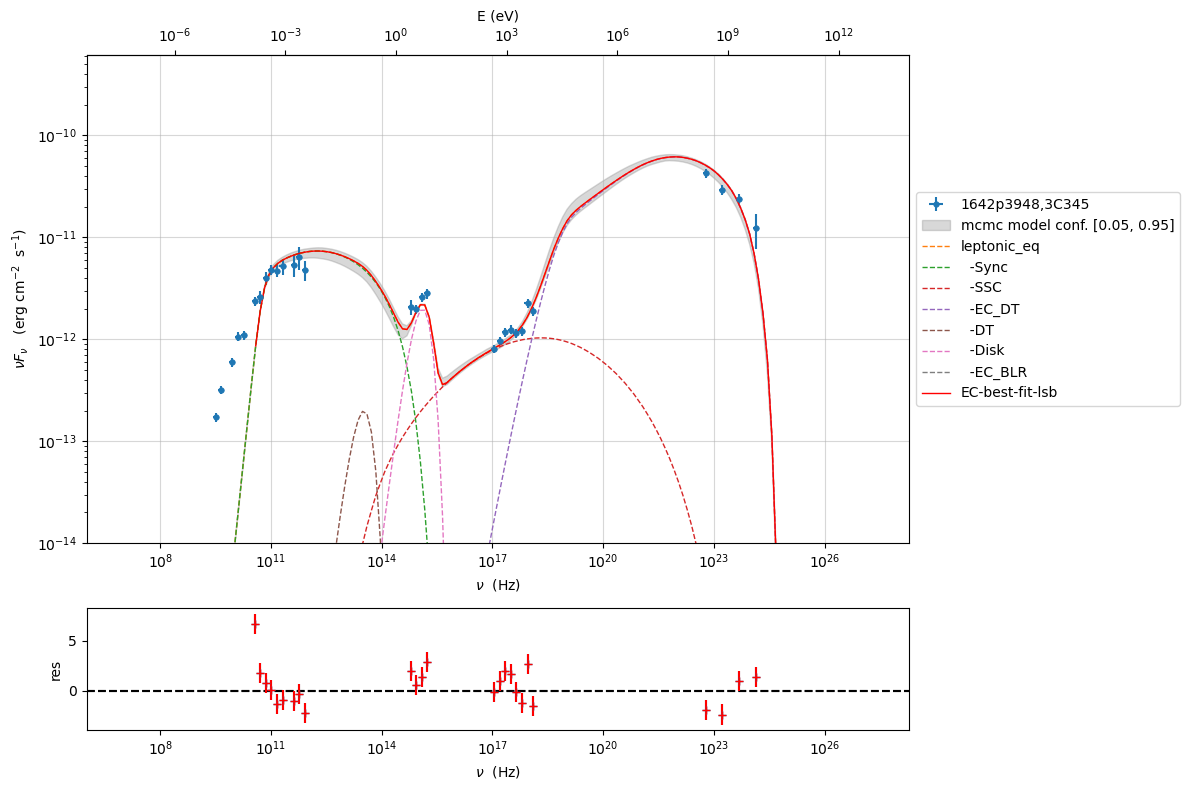

In [63]:
mpl.rcParams['figure.dpi'] = 100
p=mcmc.plot_model(sed_data=sed_data,size=500,quantiles=[0.05,0.95], plot_mcmc_best_fit_model=False,plot_components=True)
p.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

### plotting chains and individual posteriors

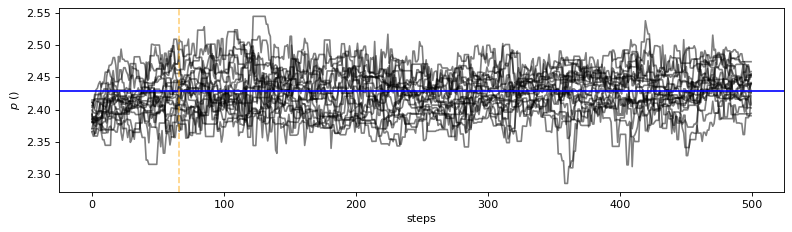

In [64]:
import matplotlib.pylab as plt

mpl.rcParams['figure.dpi'] = 80
f=mcmc.plot_chain(par_name='p',log_plot=False)
plt.tight_layout()

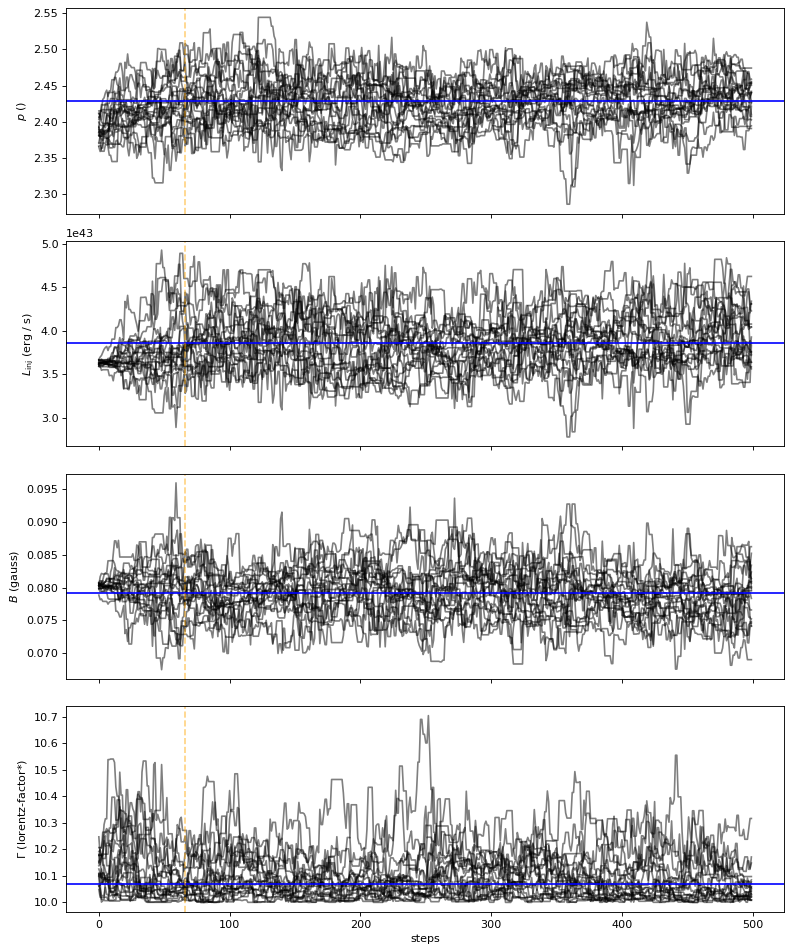

In [65]:
mpl.rcParams['figure.dpi'] = 80
f=mcmc.plot_chain(log_plot=False)
plt.tight_layout()

## Save and reuse MCMC

In [66]:
mcmc.save('mcmc_sampler.pkl')

In [67]:
from jetset.mcmc import McmcSampler
from jetset.data_loader import ObsData
from jetset.plot_sedfit import PlotSED
from jetset.test_data_helper import  test_SEDs

sed_data=ObsData.load('3C454_data.pkl')

ms=McmcSampler.load('mcmc_sampler.pkl')

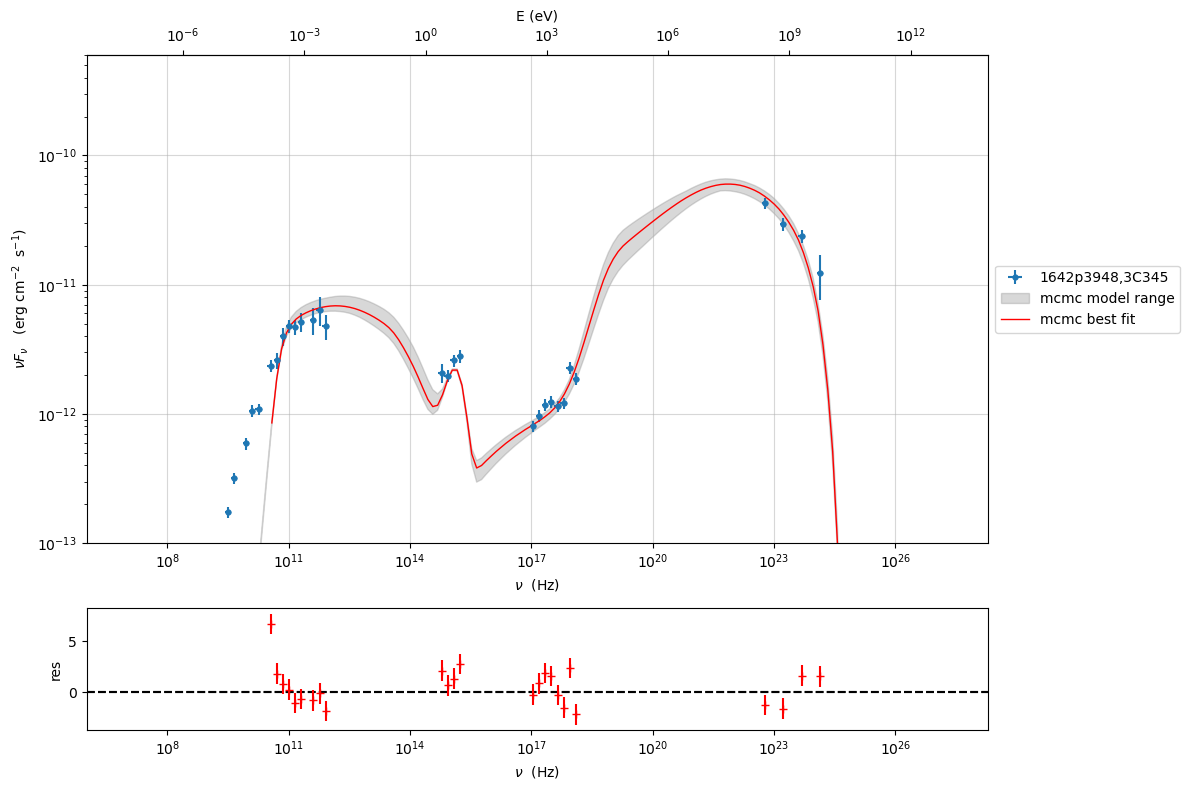

In [68]:
ms.model.set_nu_grid(1E6,1E30,200)

p=ms.plot_model(sed_data=sed_data,fit_range=[3E10, 1E29],size=100)
p.setlim(y_min=1E-13,x_min=1E6,x_max=2E28)

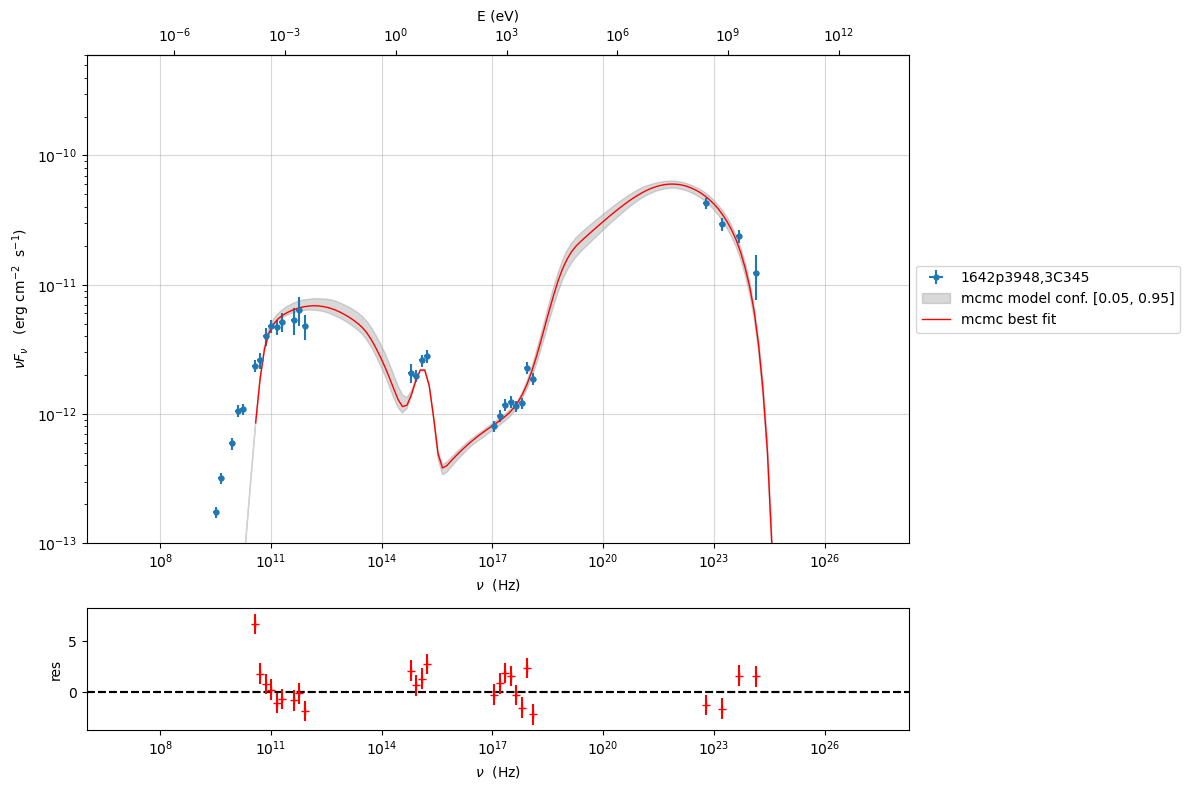

In [69]:
p=ms.plot_model(sed_data=sed_data,fit_range=[3E10, 1E29],size=100,quantiles=[0.05,0.95])
p.setlim(y_min=1E-13,x_min=1E6,x_max=2E28)

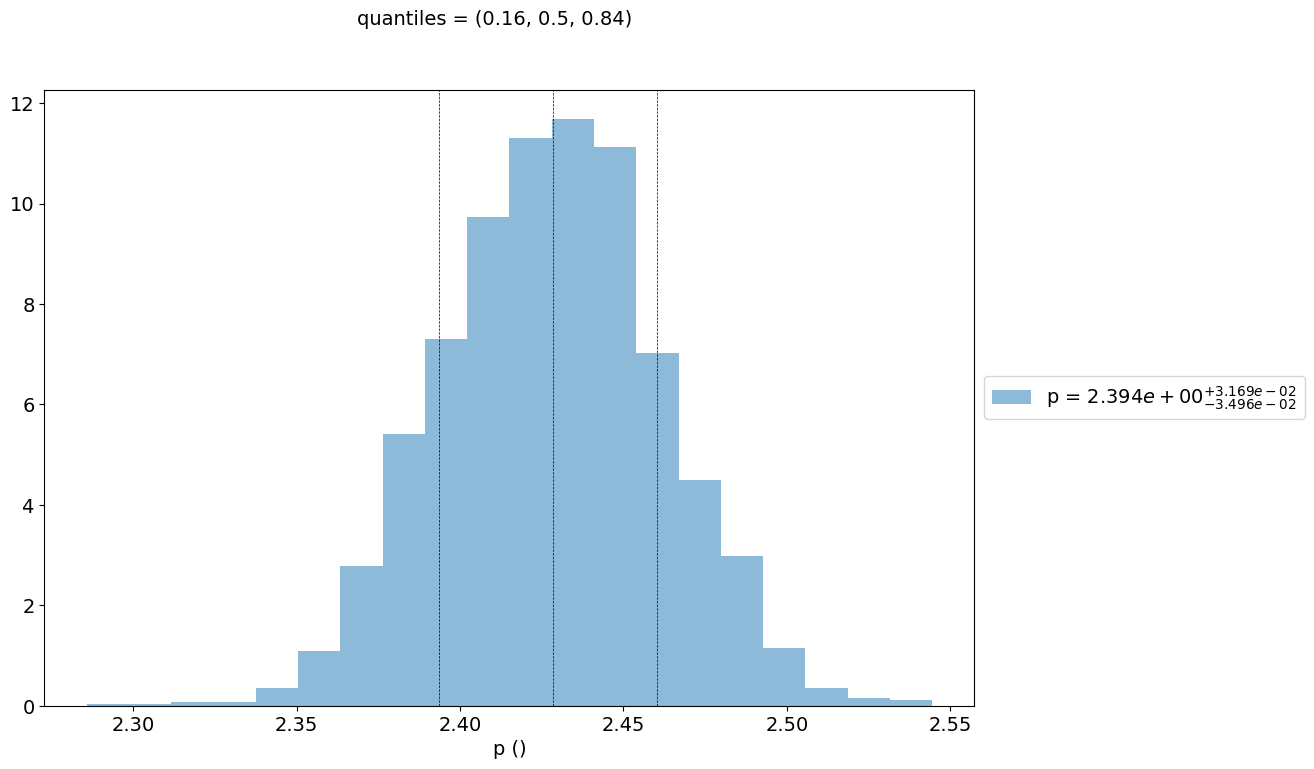

In [71]:
f=ms.plot_par('p',log_plot=False)
